In [1]:
# General notebook settings
import logging
import warnings

import pypsa

warnings.filterwarnings("error", category=DeprecationWarning)
# pandas<3.0.3 sets the `locs` attribute deprecated in matplotlib>=3.11
warnings.filterwarnings("ignore", message="The locs attribute was deprecated")
logging.getLogger("gurobipy").propagate = False
pypsa.options.params.optimize.log_to_console = False

# Reserve Constraints

## Objective

When using a linear programming approach in an energy system, the optimization usually results in all generators either running at full capacity or not running at all, depending on their position in the merit order.
In the real world, generators often run at partial load.
Unfortunately, most of the reasons why generators run at partial load are difficult to account for in modeling.
One reason for generators to run at partial load is to be able to act as spinning reserves, i.e. to be able to ramp up or down quickly when needed to maintain system stability.

In this example we will implement spinning reserve constraints in PyPSA in a very simplified way.
The objective is to force some generators to provide reserve power by running below their rated capacity, but still maintain a linear programming problem formulation. 
To do this, we need to implement additional variables and additional constraints in the model.


## Methodology
We follow the approach presented by Andreas Hösl et al. in [this video](https://www.youtube.com/watch?v=fmwDxNpSMM4&t=8043s).

The basic idea is that each generator must provide reserve power **symmetrically**. This means that it must be able to increase and decrease its output by the same amount in order to contribute to meeting reserve requirements. This ensures that generators must operate at partial load to provide reserve power. 

The following changes need to be made to the linopy model in a PyPSA network:

- a new variable $p_{\text{reserve}}(g,t)$ representing the reserve power provided by generator $g$ at time step $t$. 

- a constraint that ensures that for each time step $t$, the sum of all reserve power provided is greater than or equal to the required reserves.
$$
\forall t: \sum_{g} p_{\text{reserve}}(g,t) \geq \text{reserve requirement}
$$

- A constraint to ensure that the reserve power of a generator is less than or equal to the difference between its power $p$ and its nominal power $p_\text{nom}$, multiplied by a scalar coefficient $a$. This coefficient can take any value between 0 and 1 and represents the technical availability of a generator to provide reserve power. 
$$
\forall g, t: p_\text{reserve}(g, t) \leq a(g) p_\text{nom}(g) - p(g,t)
$$

- a constraint to ensure that the reserve power of a generator is less than or equal to its actual power $p$ multiplied by a scalar coefficient $b$. This coefficient can take any value between 0 and 1 and represents the technical availability of a generator to provide reserve power. 

$$
\forall g, t: p_\text{reserve}(g, t) \leq b(g) p(g,t)
$$

The relationships between the variables $a$, $b$, $p_\text{nom}$, $p$ and $p_\text{reserve}$ are shown in the following schematic diagram.

![reserve-power-graph](../../doc/img/reserve-power-graph.png)

## Limitations and other approaches

Note that this is an oversimplified approach that has significant limitations:
- It does not distinguish between different categories of reserves, such as primary or secondary reserves. 
- Reserves are provided symmetrically; there is no distinction between positive and negative reserves.
- The approach only considers the provision of reserve power, not the actual delivery.
  The additional constraints simply force some generators to run at partial load so that they **could** ramp up or down when reserves are required.  

All of these issues can be addressed in a MIP unit commitment model, albeit at a much higher numerical cost. 


## Implementation

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa

### Basic model

Our toy model consists of a single bus with generators that have different marginal costs. We use a sine function for the load profile.

In [3]:
n_basic = pypsa.Network()
n_basic.add("Carrier", name="carrier1")
n_basic.add("Bus", name="bus1", carrier="carrier1")

# add generators with increasing marginal cost
n_basic.add("Generator", name="gen1", bus="bus1", p_nom=10, marginal_cost=1)
n_basic.add("Generator", name="gen2", bus="bus1", p_nom=10, marginal_cost=2)
n_basic.add("Generator", name="gen3", bus="bus1", p_nom=10, marginal_cost=3)
n_basic.add("Generator", name="gen4", bus="bus1", p_nom=10, marginal_cost=4)

# create 48 snapshots
snapshots = np.arange(1, 49)
n_basic.set_snapshots(snapshots)

# create load
load_max = 30
load_profile = np.sin(snapshots / 12 * np.pi) + 3.5
load_profile = load_profile / load_profile.max() * load_max
n_basic.add("Load", name="load1", bus="bus1", p_set=load_profile)

/home/runner/work/PyPSA/PyPSA/pypsa/network/io.py:2082: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)


We make a copy of the basic model, which we later modify to add reserve power constraints.

In [4]:
n_reserve = n_basic.copy()

As a reference point, we solve the model without any additional constraints.


In [5]:
n_basic.optimize()

/tmp/ipykernel_7572/3139818580.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_basic.optimize()


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.02s


Set parameter WLSAccessID


...

obj: 432 rows, 192 columns, 576 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 192 primals, 432 duals
Objective: 1.95e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 1.95e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

We plot the dispatch over time. As expected, the generators are dispatched strictly according to their marginal cost, each one running at nominal capacity until demand is met. 

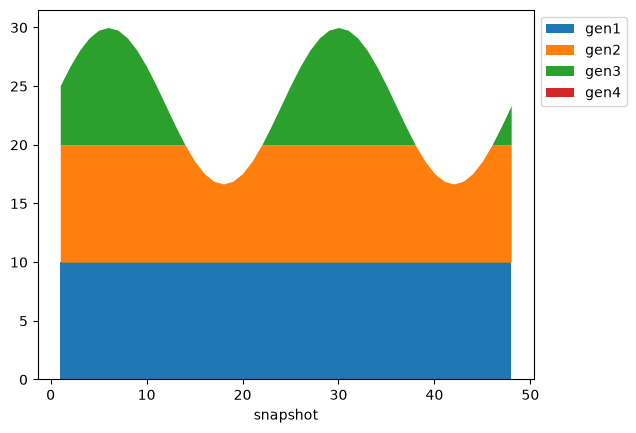

In [6]:
n_basic.generators_t["p"].plot.area(lw=0).legend(
    loc="upper left", bbox_to_anchor=(1.0, 1.0)
)
plt.show()

### Modified model with custum variable and constraints

Now let's modify the model by adding some additional constraints.
We create a new network and create a model instance attached to it.
Now we can inspect the model instance to get a list of variables and constraints: 

In [7]:
n_reserve.optimize.create_model()
n_reserve.model

/opt/hostedtoolcache/Python/3.13.15/x64/lib/python3.13/contextlib.py:85: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  return func(*args, **kwds)


Linopy LP model

Variables:
----------
 * Generator-p (snapshot, name)

Expressions:
------------
<empty>

Constraints:
------------
 * Generator-fix-p-lower (snapshot, name)
 * Generator-fix-p-upper (snapshot, name)
 * Bus-nodal_balance (snapshot, name)

Status:
-------
initialized

We now add a new variable ``p_reserve`` which represents the reserve power.
It has a lower bound of zero, is defined for all dispatchable generators and has a time index.

In [8]:
v_rp = n_reserve.model.add_variables(
    lower=0,
    coords=[n_reserve.snapshots, n_reserve.generators.index],
    name="Generator-p_reserve",
)
v_rp

Variable (snapshot: 48, name: 4)
--------------------------------
[1, gen1]: Generator-p_reserve[1, gen1] ∈ [0, inf]
[1, gen2]: Generator-p_reserve[1, gen2] ∈ [0, inf]
[1, gen3]: Generator-p_reserve[1, gen3] ∈ [0, inf]
[1, gen4]: Generator-p_reserve[1, gen4] ∈ [0, inf]
[2, gen1]: Generator-p_reserve[2, gen1] ∈ [0, inf]
[2, gen2]: Generator-p_reserve[2, gen2] ∈ [0, inf]
[2, gen3]: Generator-p_reserve[2, gen3] ∈ [0, inf]
		...
[47, gen2]: Generator-p_reserve[47, gen2] ∈ [0, inf]
[47, gen3]: Generator-p_reserve[47, gen3] ∈ [0, inf]
[47, gen4]: Generator-p_reserve[47, gen4] ∈ [0, inf]
[48, gen1]: Generator-p_reserve[48, gen1] ∈ [0, inf]
[48, gen2]: Generator-p_reserve[48, gen2] ∈ [0, inf]
[48, gen3]: Generator-p_reserve[48, gen3] ∈ [0, inf]
[48, gen4]: Generator-p_reserve[48, gen4] ∈ [0, inf]

Next, we define a new constraint which ensures that for each snapshot the total reserve requirement is satisfied by the sum of the reserve power provided by all generators.


In [9]:
reserve_req = 10

c_sum = n_reserve.model.add_constraints(
    v_rp.sum("name") >= reserve_req, name="GlobalConstraint-sum_of_reserves"
)
c_sum

Constraint `GlobalConstraint-sum_of_reserves` [snapshot: 48]:
-------------------------------------------------------------
[1]: +1 Generator-p_reserve[1, gen1] + 1 Generator-p_reserve[1, gen2] + 1 Generator-p_reserve[1, gen3] + 1 Generator-p_reserve[1, gen4]      ≥ 10.0
[2]: +1 Generator-p_reserve[2, gen1] + 1 Generator-p_reserve[2, gen2] + 1 Generator-p_reserve[2, gen3] + 1 Generator-p_reserve[2, gen4]      ≥ 10.0
[3]: +1 Generator-p_reserve[3, gen1] + 1 Generator-p_reserve[3, gen2] + 1 Generator-p_reserve[3, gen3] + 1 Generator-p_reserve[3, gen4]      ≥ 10.0
[4]: +1 Generator-p_reserve[4, gen1] + 1 Generator-p_reserve[4, gen2] + 1 Generator-p_reserve[4, gen3] + 1 Generator-p_reserve[4, gen4]      ≥ 10.0
[5]: +1 Generator-p_reserve[5, gen1] + 1 Generator-p_reserve[5, gen2] + 1 Generator-p_reserve[5, gen3] + 1 Generator-p_reserve[5, gen4]      ≥ 10.0
[6]: +1 Generator-p_reserve[6, gen1] + 1 Generator-p_reserve[6, gen2] + 1 Generator-p_reserve[6, gen3] + 1 Generator-p_reserve[6, gen4] 

Now we need to limit the amount of reserve power that each generator can provide. The following constraint ensures that the reserve power provided by a generator must be less than or equal to the difference between its power ``p``  and its nominal power ``p_nom``:

In [10]:
a = 1

c_rpos = n_reserve.model.add_constraints(
    v_rp
    <= -n_reserve.model.variables["Generator-p"] + a * n_reserve.generators["p_nom"],
    name="Generator-reserve_upper_limit",
)
c_rpos

Constraint `Generator-reserve_upper_limit` [snapshot: 48, name: 4]:
-------------------------------------------------------------------
[1, gen1]: +1 Generator-p_reserve[1, gen1] + 1 Generator-p[1, gen1]    ≤ 10.0
[1, gen2]: +1 Generator-p_reserve[1, gen2] + 1 Generator-p[1, gen2]    ≤ 10.0
[1, gen3]: +1 Generator-p_reserve[1, gen3] + 1 Generator-p[1, gen3]    ≤ 10.0
[1, gen4]: +1 Generator-p_reserve[1, gen4] + 1 Generator-p[1, gen4]    ≤ 10.0
[2, gen1]: +1 Generator-p_reserve[2, gen1] + 1 Generator-p[2, gen1]    ≤ 10.0
[2, gen2]: +1 Generator-p_reserve[2, gen2] + 1 Generator-p[2, gen2]    ≤ 10.0
[2, gen3]: +1 Generator-p_reserve[2, gen3] + 1 Generator-p[2, gen3]    ≤ 10.0
		...
[47, gen2]: +1 Generator-p_reserve[47, gen2] + 1 Generator-p[47, gen2] ≤ 10.0
[47, gen3]: +1 Generator-p_reserve[47, gen3] + 1 Generator-p[47, gen3] ≤ 10.0
[47, gen4]: +1 Generator-p_reserve[47, gen4] + 1 Generator-p[47, gen4] ≤ 10.0
[48, gen1]: +1 Generator-p_reserve[48, gen1] + 1 Generator-p[48, gen1] ≤ 10.0


Finally, we add a constraint to ensure that the reserve power provided by a generator must be less than or equal to its actual power ``p`` multiplied by a scalar coefficient ``b``.
This coefficient can take any value between 0 and 1 and represents the technical availability of a generator to provide reserve power.

In [11]:
b = 0.7

c_rneg = n_reserve.model.add_constraints(
    v_rp <= b * n_reserve.model.variables["Generator-p"],
    name="Generator-reserve_lower_limit",
)
c_rneg

Constraint `Generator-reserve_lower_limit` [snapshot: 48, name: 4]:
-------------------------------------------------------------------
[1, gen1]: +1 Generator-p_reserve[1, gen1] - 0.7 Generator-p[1, gen1]    ≤ -0.0
[1, gen2]: +1 Generator-p_reserve[1, gen2] - 0.7 Generator-p[1, gen2]    ≤ -0.0
[1, gen3]: +1 Generator-p_reserve[1, gen3] - 0.7 Generator-p[1, gen3]    ≤ -0.0
[1, gen4]: +1 Generator-p_reserve[1, gen4] - 0.7 Generator-p[1, gen4]    ≤ -0.0
[2, gen1]: +1 Generator-p_reserve[2, gen1] - 0.7 Generator-p[2, gen1]    ≤ -0.0
[2, gen2]: +1 Generator-p_reserve[2, gen2] - 0.7 Generator-p[2, gen2]    ≤ -0.0
[2, gen3]: +1 Generator-p_reserve[2, gen3] - 0.7 Generator-p[2, gen3]    ≤ -0.0
		...
[47, gen2]: +1 Generator-p_reserve[47, gen2] - 0.7 Generator-p[47, gen2] ≤ -0.0
[47, gen3]: +1 Generator-p_reserve[47, gen3] - 0.7 Generator-p[47, gen3] ≤ -0.0
[47, gen4]: +1 Generator-p_reserve[47, gen4] - 0.7 Generator-p[47, gen4] ≤ -0.0
[48, gen1]: +1 Generator-p_reserve[48, gen1] - 0.7 Generat

We can now inspect the model formulation. We can see that our new variables and constraints have been successfully added:

In [12]:
n_reserve.model

Linopy LP model

Variables:
----------
 * Generator-p (snapshot, name)
 * Generator-p_reserve (snapshot, name)

Expressions:
------------
<empty>

Constraints:
------------
 * Generator-fix-p-lower (snapshot, name)
 * Generator-fix-p-upper (snapshot, name)
 * Bus-nodal_balance (snapshot, name)
 * GlobalConstraint-sum_of_reserves (snapshot)
 * Generator-reserve_upper_limit (snapshot, name)
 * Generator-reserve_lower_limit (snapshot, name)

Status:
-------
initialized

We can now solve the modified model:

In [13]:
n_reserve.optimize.solve_model()

INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.03s


Set parameter WLSAccessID


Set parameter WLSSecret


...

obj: 864 rows, 384 columns, 1536 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 384 primals, 864 duals
Objective: 2.30e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 2.30e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, GlobalConstraint-sum_of_reserves, Generator-reserve_upper_limit, Generator-reserve_lower_limit were not assigned to the network.


('ok', 'optimal')

### Examine the results

We create a plot to examine the results of the modified model.
On the left subplot we plot the active power generation `p` over time for each generator.
On the right subplot we plot the reserve power `p_reserve` over time for each generator.
The following observations can be made:

- The reserve requirement of 20 MW is met in every time step.
- In order to provide reserves, some generators must always run below their nominal power.
- Among all running generators, those with the highest marginal costs provide as much reserve capacity as possible. 
 

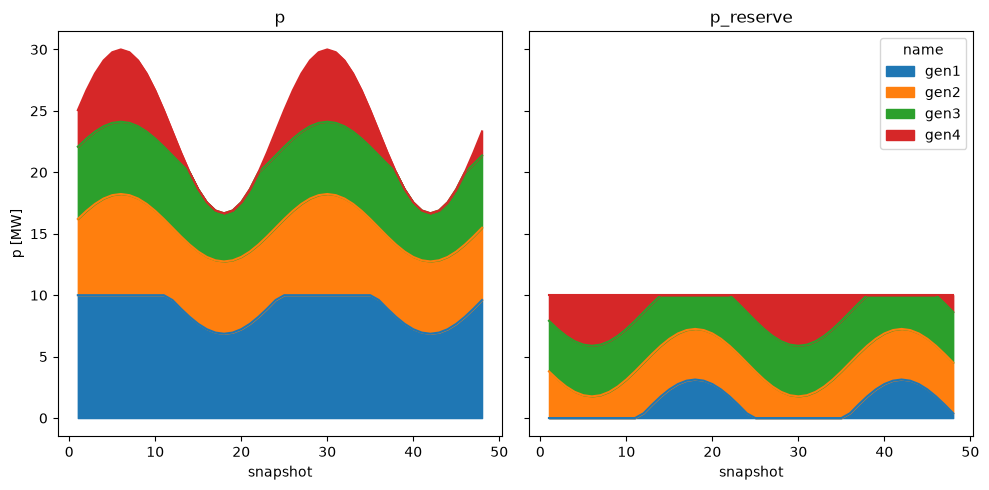

In [14]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
n_reserve.generators_t["p"].plot.area(
    ax=axs[0], title="p", legend=False, ylabel="p [MW]"
)
n_reserve.generators_t["p_reserve"].plot.area(ax=axs[1], title="p_reserve")
plt.tight_layout()
plt.show()

Looking at the average reserve power provided by a generator, we can see that the cheapest and most expensive generators provide less reserve power on average than the other two generators.

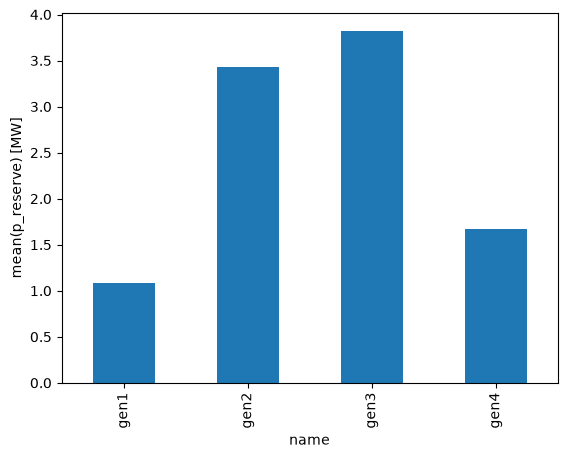

In [15]:
n_reserve.generators_t["p_reserve"].mean().plot(
    kind="bar", ylabel="mean(p_reserve) [MW]"
)
plt.show()

### Comparison of the two model versions

To visually compare the base model with the modified model, we plot the active power generation `p` over time for both models. On the left we plot the base model, on the right we plot the model with additional constraints.

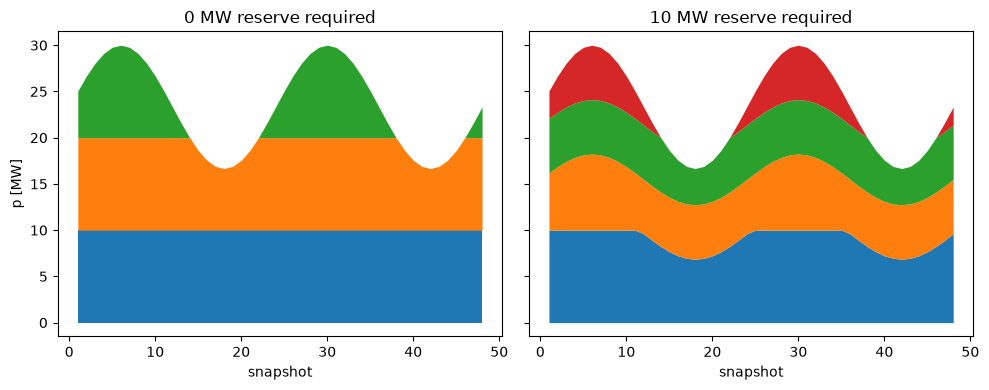

In [16]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 4))
for i, (n, r) in enumerate([(n_basic, 0), (n_reserve, reserve_req)]):
    n.generators_t["p"].plot.area(
        ax=axs[i], ylabel="p [MW]", title=f"{r} MW reserve required", legend=False, lw=0
    )

plt.tight_layout()
plt.show()

We can also compare average power and reserve power over time.
The graph shows that adding reserve constraints reduces the average generation of the cheaper generators and increases the average generation of the more expensive generators.

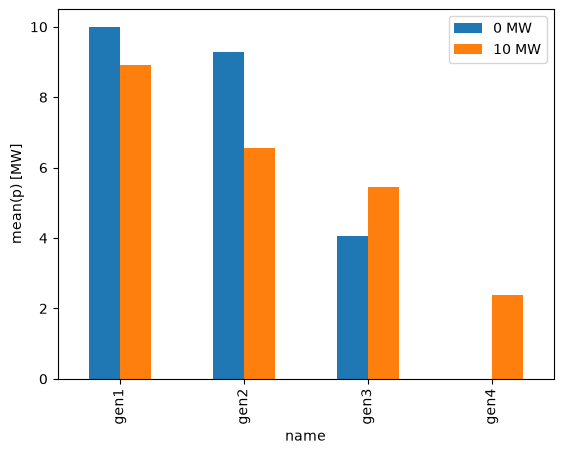

In [17]:
data = pd.concat(
    [n.generators_t.get("p").mean() for n in [n_basic, n_reserve]],
    axis=1,
    keys=["0 MW", f"{reserve_req} MW"],
)
data.plot(kind="bar", ylabel="mean(p) [MW]")
plt.show()

And that's it. Feel free to change the values of ``reserve_req``, ``a`` and ``b`` and see how this affects the results.
However, be aware that reserve requirements that are too high can make the model infeasible.

You can also try out an interactive dashboard to play around with a small example model where you can try out different reserve settings at https://pypsa-reserves-dashboard.streamlit.app/ 

## Acknowledgements

The contribution of this example has been funded as part of the IND-E project.

![reserve-power-funding](../../docs/assets/images/reserve-power-funding.gif)